<a href="https://colab.research.google.com/github/hudamohmand/undergrad_ml_assignments/blob/main/Linear_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 3: Linear Models

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

**Q1: Answers**
1. A model is linear if the parameters appear linearly and the dependent variable is a linear combination of the of the parameters and independent variables.
2. You can interpret it as the difference/change compared to the reference group.
3. Technically yes, if you are prediciting a continuous output but it is not the most ideal to use for classification because linear regression does not keep the predicitions between a specific range of probabilities so it is not as reliable for classification.
4. Some signs a model is over-fitting include: too many variables, a large variance in the predicitions, error is high, and if the model fits the training data well but not the test data well.
5. Multicolinearity happens when one variable in a regression can be predicted using the other variables. There can be two steps to this, first, you regress one predictor on all the other ones and examine R^2, and if it is very high, it indicates strong multicolineraity. In the second stage, when you run the regression, the linear dependence being high will make it difficult to identify how each variable effects the outcome, making it hard to interpret the results.
6. You can incorporate non-linear relationships by using log or adding polynomial terms.
7. It tells you on average how much Y changes by beta units for a one-unit increase in X.
8. For Train/Test you split once but for k-fold you split into k parts, making k-fold more reliable.
9. It is typically based on the bias and variance.

**Q2: Part 1**

In [ ]:
import pandas as pd

df = pd.read_csv('Q1_clean.csv')

df.columns = df.columns.str.strip()
df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean()

,Price,Review Scores Rating
Neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


The most expensive bourough is Manhattan.

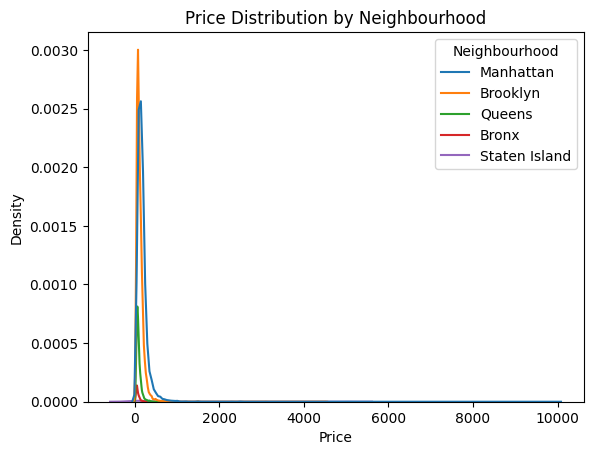

In [ ]:
sns.kdeplot(data=df, x='Price', hue='Neighbourhood')
plt.title('Price Distribution by Neighbourhood')
plt.show()

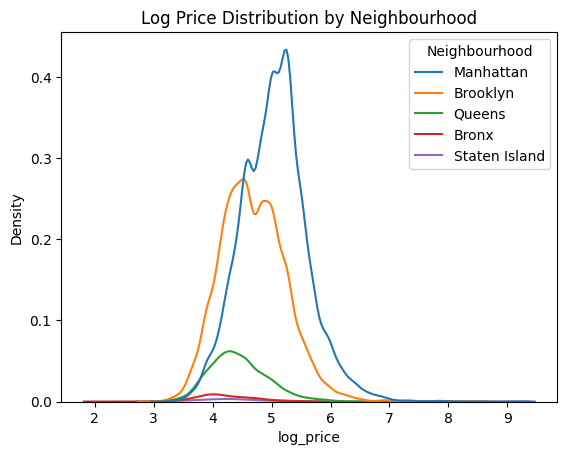

In [ ]:
df['log_price'] = np.log(df['Price'])
sns.kdeplot(data=df, x='log_price', hue='Neighbourhood')
plt.title('Log Price Distribution by Neighbourhood')
plt.show()

**Q2: Part 2**

In [ ]:
dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True)
dummies.head()

,Brooklyn,Manhattan,Queens,Staten Island
0,False,True,False,False
1,True,False,False,False
2,False,True,False,False
3,True,False,False,False
4,False,True,False,False


In [ ]:
dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True).astype(int)

In [ ]:
import statsmodels.api as sm

X = sm.add_constant(dummies)
y = df['Price']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        15:35:13   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

I dropped the first category to avoid the dummy variable trap. Each coefficient in the table, represents the difference in average price between that neighborhood and the bronx because the bronx became the baseline group.

**Q2: Part 3**

In [ ]:
X = sm.add_constant(df['Review Scores Rating'])
y = df['Price']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        15:40:09   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   60.8784 

A coefficient of 1.02 represents that price increase on average.

**Q2: Part 4**

In [ ]:
X = pd.concat([df['Review Scores Rating'], dummies], axis=1)
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        15:41:58   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -23.8126 

**Q2: Part 5**

In [ ]:
for col in dummies.columns:
    df['rating_' + col] = df['Review Scores Rating'] * dummies[col]

X = pd.concat([df['Review Scores Rating'], dummies], axis=1)

interaction_cols = ['rating_' + col for col in dummies.columns]
X = pd.concat([X, df[interaction_cols]], axis=1)

X = sm.add_constant(X)
y = df['Price']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Thu, 26 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:44:40   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   22.6384 

**Q2: Part 6**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
X4 = dummies
y = df['Price']
model4 = LinearRegression()
cv4 = cross_val_score(model4, X4, y, cv=10, scoring='neg_mean_squared_error')

X5 = df[['Review Scores Rating']]
model5 = LinearRegression()
cv5 = cross_val_score(model5, X5, y, cv=10, scoring='neg_mean_squared_error')
X6 = pd.concat([df[['Review Scores Rating']], dummies], axis=1)
model6 = LinearRegression()
cv6 = cross_val_score(model6, X6, y, cv=10, scoring='neg_mean_squared_error')

print("Model 4 MSE:", -cv4.mean())
print("Model 5 MSE:", -cv5.mean())
print("Model 6 MSE:", -cv6.mean())

Model 4 MSE: 21181.0143060228
Model 5 MSE: 22092.66808869053
Model 6 MSE: 21095.14231724225


Neighborhood is the most important predictor.

**Q3: Part 1**

In [ ]:
cars = pd.read_csv('cars_hw.csv')
cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [ ]:
cars['Price'].describe()

,Price
count,9.760000e+02
mean,7.410195e+05
std,3.673234e+05
min,1.880000e+05
25%,4.757500e+05
50%,6.665000e+05
75%,8.830000e+05
max,2.941000e+06


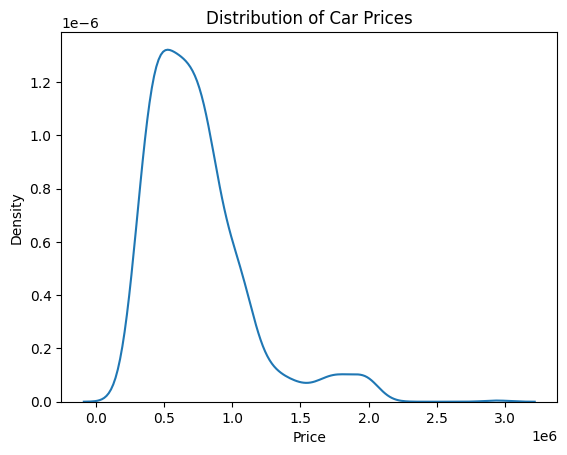

In [ ]:
sns.kdeplot(data=cars, x='Price')
plt.title('Distribution of Car Prices')
plt.show()

In [ ]:
cars.groupby('Body_Type')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


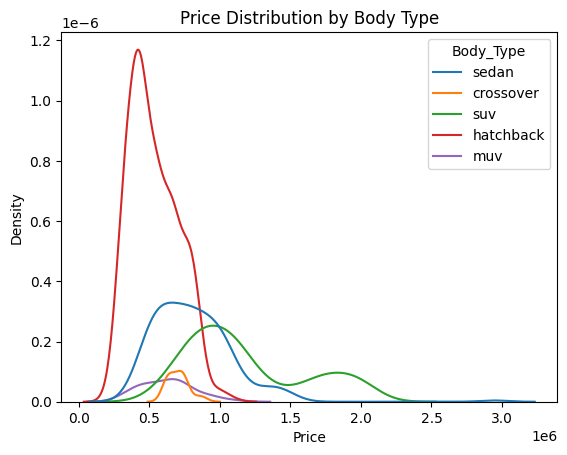

In [ ]:
sns.kdeplot(data=cars, x='Price', hue='Body_Type')
plt.title('Price Distribution by Body Type')
plt.show()

Prices are quite spread out and a bit right skewed. SUVs are the most expensive and have the highest standard deviation meaning their prices vary the most.

**Q3: Part 2**


In [ ]:
X = cars['Seating_Capacity']
X = sm.add_constant(X)

y = cars['Price']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Mon, 30 Mar 2026   Prob (F-statistic):             0.0245
Time:                        00:20:47   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

In [ ]:
X = pd.get_dummies(cars['Seating_Capacity'], drop_first=True)

X = X.astype(float)

X = sm.add_constant(X)

model_cat = sm.OLS(cars['Price'], X).fit()
print(model_cat.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           0.000267
Time:                        00:20:49   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.88e+05   3.64e+05      0.516      0.6

Prices do not increase in a linear way as seating capacity increases.

**Q3: Part 3**

In [ ]:
cars['Age'] = 2024 - cars['Make_Year']


In [ ]:
def compute_cv_error(degree):
    kf = KFold(n_splits=10, shuffle=True, random_state=1)
    errors = []

    for train_index, test_index in kf.split(cars):
        train = cars.iloc[train_index]
        test = cars.iloc[test_index]

        X_train = train[['Age']].copy()
        X_test = test[['Age']].copy()

        for d in range(2, degree + 1):
            X_train['Age_' + str(d)] = X_train['Age'] ** d
            X_test['Age_' + str(d)] = X_test['Age'] ** d

        X_train = sm.add_constant(X_train)
        X_test = sm.add_constant(X_test)

        model = sm.OLS(train['Price'], X_train).fit()
        preds = model.predict(X_test)

        error = mean_squared_error(test['Price'], preds)
        errors.append(error)

    return np.mean(errors)

In [ ]:
for d in range(1, 6):
    print("Degree", d, "MSE:", compute_cv_error(d))

Degree 1 MSE: 97745760011.44073
Degree 2 MSE: 97815319552.31631
Degree 3 MSE: 97304076284.38504
Degree 4 MSE: 96785385468.53622
Degree 5 MSE: 95816293469.9592


Looking at the output of my 10-fold cross validation, the results show that MSE decreases as degree decreases therefore, degree 5 has the lowest MSE. So the optimal age to include is 5.

**Q3: Part 4**

In [ ]:
cars['Age_2'] = cars['Age'] ** 2
cars['Age_3'] = cars['Age'] ** 3

X = cars[['Age', 'Age_2', 'Age_3']]
X = sm.add_constant(X)

model = sm.OLS(cars['Price'], X).fit()

cars['Predicted_Price'] = model.predict(X)

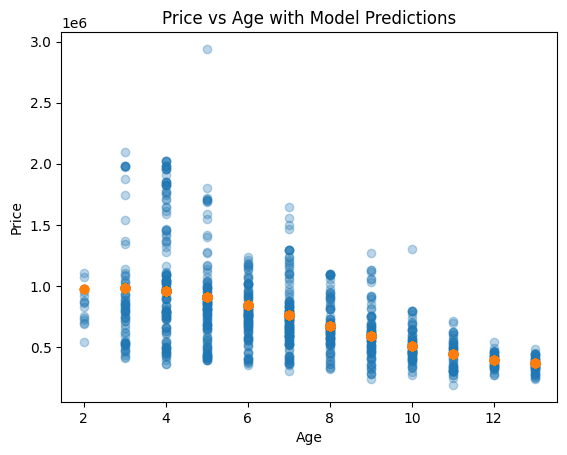

In [ ]:
plt.scatter(cars['Age'], cars['Price'], alpha=0.3)
plt.scatter(cars['Age'], cars['Predicted_Price'], alpha=0.3)

plt.xlabel('Age')
plt.ylabel('Price')
plt.title('Price vs Age with Model Predictions')

plt.show()

Price generally decreases as age increases.

**Q4: Part 1**

In [7]:
df = pd.read_csv('heart_hw.csv')

control_mean = df[df['transplant'] == 'control']['y'].mean()

treatment_mean = df[df['transplant'] == 'treatment']['y'].mean()

ate = treatment_mean - control_mean

print('Control survival rate:', control_mean)
print('Treatment survival rate:', treatment_mean)
print('ATE:', ate)

Control survival rate: 0.11764705882352941
Treatment survival rate: 0.34782608695652173
ATE: 0.23017902813299232


**Q4: Part 2**

In [8]:
df['transplant_dummy'] = df['transplant'] == 'treatment'
df['transplant_dummy'] = df['transplant_dummy'].astype(int)

X = sm.add_constant(df['transplant_dummy'])
y = df['y']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Wed, 01 Apr 2026   Prob (F-statistic):             0.0133
Time:                        02:08:40   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.1176      0.075  

**Q4: Part 3**

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           0.000357
Time:                        02:16:34   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.7020      0.196  

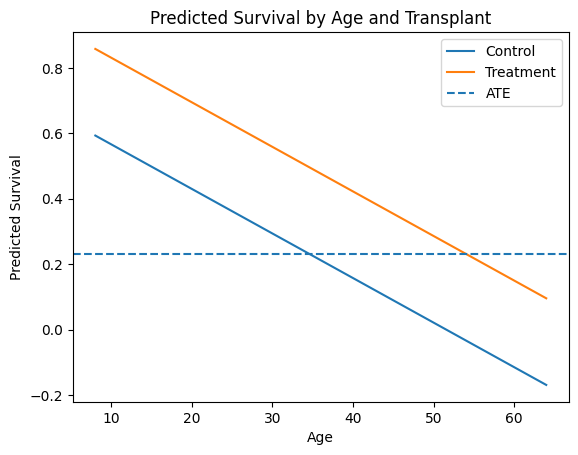

In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

df['transplant_dummy'] = df['transplant'] == 'treatment'
df['transplant_dummy'] = df['transplant_dummy'].astype(int)

X = df[['transplant_dummy', 'age']]
X = sm.add_constant(X)

y = df['y']

model = sm.OLS(y, X).fit()

print(model.summary())

age_range = np.linspace(df['age'].min(), df['age'].max(), 100)

X_control = pd.DataFrame({
    'const': 1,
    'transplant_dummy': 0,
    'age': age_range
})

X_treatment = pd.DataFrame({
    'const': 1,
    'transplant_dummy': 1,
    'age': age_range
})

pred_control = model.predict(X_control)
pred_treatment = model.predict(X_treatment)

ATE = df[df['transplant'] == 'treatment']['y'].mean() - df[df['transplant'] == 'control']['y'].mean()

plt.figure()

plt.plot(age_range, pred_control, label='Control')
plt.plot(age_range, pred_treatment, label='Treatment')

plt.axhline(y=ATE, linestyle='--', label='ATE')

plt.xlabel('Age')
plt.ylabel('Predicted Survival')
plt.title('Predicted Survival by Age and Transplant')
plt.legend()

plt.show()